# Effects on circular areas
Este es el tercer scripts de los que tengo para estimar efectos, lo más seguro es que si algún día regreso a ver esto no voy a saber por qué tengo tantos, así que aquí te dejo una breve explicación: el primero es el que se llama `estimating-effects` y fue el más básico; literalmente me puse a calcular los efectos ahí mismo con el modelo de OLS. Luego de ese cree el archivo que se llama `using-classes-for-effects`, en donde hago uso de las clases que ya se encargan de todo, sobre todo porque sino se pierde la replicabilidad.  
Hoy estoy haciendo este archivo porque hice cambios en la forma en cómo hago el matching, para eliminar las unidades que están fuera de soporte, además de que me aseguré de que el match fuera mejor, al elegir la combinación de variables que redujera el SMD de todas las covariables, así que hoy tengo que copiar y pegar todo otra vez en el sheets :(, pero ya casi estoy terminando

## Imports

In [1]:
import os
import sys
import pickle
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Agregar el directorio base (scripts) al path para importar las clases
sys.path.append(os.path.abspath('..'))

from ps_features_builder import PSFeaturesBuilder
from effect_estimation import EffectEstimation
from ps_matching import PSMatching

## Constants

In [5]:
# Definición de rutas a los archivos
PATH_DATA = '../../data/'
PATHS = {
    'vialidades': os.path.join(PATH_DATA, 'vialidades.json'),
    'speed_cameras': os.path.join(PATH_DATA, 'fotocivicas-ubicacion-puntos', 'fotocivicas-ubicacion-puntos.shp'),
    'metro_coordinates': os.path.join(PATH_DATA, 'metro-station-coordinates.parquet'),
    'afluencia_metro': os.path.join(PATH_DATA, 'afluencia-metro-semanal.parquet'),
    'classified_incidents': os.path.join(PATH_DATA, 'classified-incidents.parquet'),
    'volumen_mensual': os.path.join(PATH_DATA, 'volumen-total-mensual.parquet'),
    'ps_feature_builders' : os.path.join(PATH_DATA, "pickle_objects", "ps_features_builder")
}

# grid_type, radio, n_circles
radios = [
    ("circular", 37.5, 25), # 0
    ("circular", 50, 15), # 1
    ("circular", 100, 20), # 2
    ("circular", 150, 15), # 3
    ("circular", 200, 20), # 4
    ("circular", 250, 25), # 5
]

object_name_format = "{grid_type}_{radio}_{n_circles}.pkl"

## Code

In [174]:
grid_type, radio, n_circles = radios[1]
print(radio)

filename = object_name_format.format(
    grid_type=grid_type,
    radio=int(radio),
    n_circles=n_circles
)
obj_path = os.path.join(PATHS.get("ps_feature_builders"), filename)
with open(obj_path, "rb") as f:
    ps_builder : PSFeaturesBuilder = pickle.load(f)

50


In [175]:
psm = PSMatching(
    ps_features=ps_builder.ps_features,
    grid=ps_builder.grid,
    outcome=ps_builder.outcome,
    grid_type=ps_builder.grid_type,
    grid_size=ps_builder.circle_radius
)
psm.build(
    matching_method="nearest",
    n_matches=1
)

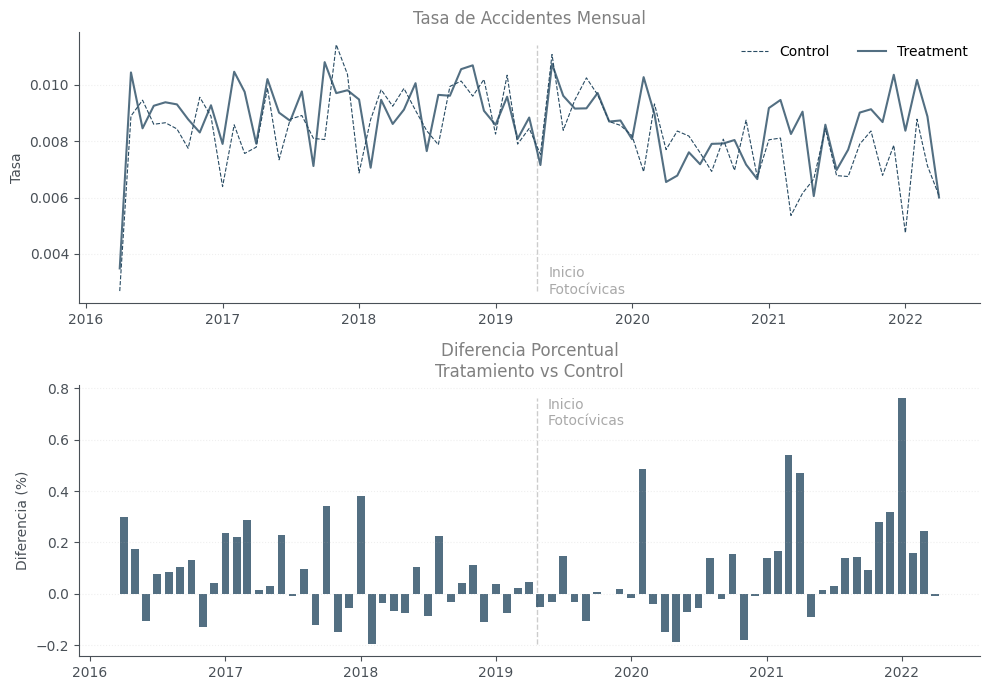

In [176]:
fig = psm.plot_outcome_trends()

In [177]:
effect_estimator = EffectEstimation(
    outcome=psm.outcome,
    matched_grids=psm.matched_grids,
    inicio_operaciones=ps_builder.inicio_operaciones
)
effect_estimator.estimate_all()

In [178]:
(
    effect_estimator
    .get_results_table(
        outcome_type="total",
        variable="total"
    )
    .transpose()
    .set_index('Intercept')
    .transpose()
    # .to_clipboard(index=False)    
)
# me lleva la puta madre, no hay absolutamente nada que sea estadísticamente significativo

Intercept,1.444 (0.03077),0.00000,
treat,0.07409 (0.04541),0.10272,
post,-0.2816 (0.04143),0.00000,
treat_post,0.03083 (0.0606),0.61086,0.71960
